# Lethiö et al, 2021: Multimodal data integration

In modern -omics experiments, it is common to measure multiple _modalities_ at once. It is a central challenge to integrate these complementary measurements to a uniform view of the biological state of the specimen. `alphapepttools` seamlessely integrates MS-proteomics data with other modalities via the shared `scverse` infrastructure. 

In this tutorial, we explore the integration of multiple modalities in a clinical settings by reanalysing the dataset by **Lehtiö et al, 2021**. In the original publication, the authors recorded a deep proteome of non-small lung cancer samples from 141 patients. They identified 6 proteomic cancer subtypes and associated them with histological subtypes, immune infiltration, and clinical outcomes. Notably, they compared the proteomic subtypes post hoc with matched measurements of RNA microarray + methylation experiments from a previous publication. Here, we demonstrate how these matched measurements can be jointly modelled in a MOFA+ analysis. 


1. **Proteomics Data**: Lehtiö, J. et al. Proteogenomics of non-small cell lung cancer reveals molecular subtypes associated with specific therapeutic targets and immune-evasion mechanisms. Nat Cancer 2, 1224–1242 (2021). [PXD020191](https://www.ebi.ac.uk/pride/archive/projects/PXD020191)

2. **RNA microarray + Methylation data** Karlsson, A. et al. Genome-wide DNA Methylation Analysis of Lung Carcinoma Reveals One Neuroendocrine and Four Adenocarcinoma Epitypes Associated with Patient Outcome. Clin Cancer Res 20, 6127–6140 (2014).

In [ ]:
import anndata as ad
import alphapepttools as apt
import pandas as pd
from alphabase.pg_reader.keys import PGCols
import numpy as np
import matplotlib.pyplot as plt

# Multimodal integration
import mudata as md
import muon

## Read and preprocess MS-proteomics data

In a first step, we will ingest and preprocess the MS-proteomics data separately from the other modalities. 

In [ ]:
report_path = apt.data.get_data("lehtioe2021_pg")

column_mapping = {
    PGCols.GENES: "Protein accession",
    PGCols.DESCRIPTION: "Description",
    "protein_coverage": "Coverage",
    "n_proteins": "Amount Proteins",
    PGCols.PROTEINS: "Proteins in group",
}
measurement_regex = r"^set\d{2}_tmt10plex_\d{3}[NC]?$"

adata = apt.io.read_pg_table(
    report_path,
    # TODO: change to "custom"
    search_engine="diann",
    column_mapping=column_mapping,
    measurement_regex=measurement_regex,
)
adata

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_66798/3899150333.py:10: SyntaxWarning: invalid escape sequence '\d'
  measurement_regex = "^set\d{2}_tmt10plex_\d{3}[NC]?$"


/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/programming/alphatools/docs/notebooks/studies/gene-symbols_table.txt already exists (46.51789855957031 MB)


AnnData object with n_obs × n_vars = 170 × 14058
    var: 'description', 'protein_coverage', 'n_proteins', 'proteins'

In [ ]:
# TODO: Standardize + simplify column names for uploaded metadata table
metadata_path = apt.data.get_data("lethioe2021_metadata")
metadata = pd.read_csv(metadata_path, sep="\t", index_col="TMT set and label")
metadata

/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/programming/alphatools/docs/notebooks/studies/lethioe2021_metadata.tsv already exists (0.035904884338378906 MB)


,SampleID,Proteome Subtype,Age,Sex,Previous_histology,WHO2015_histology,AC_mRNA_Subtype TCGA,SqCC_mRNA_Subtype TCGA,NSCLC_mRNA_Subtype Karlsson et al. 2017,SmokingStatus,...,ZFHX3_mut,TMB,Cancer_Testis_Antigens,NCPs,Purity,methylation_scores_overall,methylation_scores_promoter,MethylationPresent,PanelSeqPresent,TranscriptomicsPresent
TMT set and label,,,,,,,,,,,,,,,,,,,,,
set13_tmt10plex_129N,LU85,1,67.0,F,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,5.86458,0,8,0.30,0.491897,0.158030,True,True,True
set13_tmt10plex_128C,LU277,1,80.0,F,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,2.93229,2,5,0.25,0.525326,0.176840,True,True,True
set07_tmt10plex_126,LU376,1,72.0,M,AC,AC,Terminal respiratory unit,NaN,9.0,Never_smoker,...,0.0,2.93229,0,2,0.18,0.510334,0.170185,True,True,True
set11_tmt10plex_129C,LU1115,1,80.0,M,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,5.86458,4,5,0.31,0.505183,0.163569,True,True,True
set12_tmt10plex_128N,LU804,1,73.0,F,AC,AC,Terminal respiratory unit,NaN,5.0,Never_smoker,...,0.0,5.27812,1,7,0.38,0.533692,0.181161,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
set04_tmt10plex_128C,LU745,6,70.0,M,SqCC,SqCC,NaN,Classical,2.0,Former,...,0.0,8.79687,2,22,0.62,NaN,NaN,False,True,True
set14_tmt10plex_128C,LU1020,6,80.0,M,SqCC,SqCC,NaN,Classical,2.0,Former,...,0.0,24.04480,5,13,0.57,0.486081,0.154912,True,True,True
set06_tmt10plex_129C,LU372,6,69.0,M,SqCC,SqCC,NaN,Classical,2.0,Current,...,0.0,15.24790,9,27,0.68,0.437679,0.136954,True,True,True


In [ ]:
adata = apt.pp.add_metadata(adata, metadata, axis=0)
adata

AnnData object with n_obs × n_vars = 141 × 14058
    obs: 'SampleID', 'Proteome Subtype', 'Age', 'Sex', 'Previous_histology', 'WHO2015_histology', 'AC_mRNA_Subtype TCGA', 'SqCC_mRNA_Subtype TCGA', 'NSCLC_mRNA_Subtype Karlsson et al. 2017', 'SmokingStatus', 'SmokingStatus_Binary', 'Stage_general', 'Stage_detailed', 'OS_years', 'OSbin', 'Relapse_years', 'Relapse_bin', 'Adjuvant_therapy', 'PDL1_IHC', 'CD3_Stromal_IHC', 'CD8_Stromal_IHC', 'Stroma_Estimate', 'Immune_Estimate', 'ARID1A_mut', 'ARID2_mut', 'ASXL1_mut', 'ATM_mut', 'BLM_mut', 'BRAF_mut', 'CDKN2A_mut', 'EGFR_mut', 'FAT1_mut', 'KEAP1_mut', 'KMT2C_mut', 'KMT2D_mut', 'KRAS_mut', 'NF1_mut', 'NFE2L2_mut', 'NOTCH2_mut', 'PIK3CA_mut', 'POLD1_mut', 'PTEN_mut', 'RB1_mut', 'RBM10_mut', 'SMARCA4_mut', 'STK11_mut', 'TP53_mut', 'ZFHX3_mut', 'TMB', 'Cancer_Testis_Antigens', 'NCPs', 'Purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'MethylationPresent', 'PanelSeqPresent', 'TranscriptomicsPresent'
    var: 'description', 'pr

### Quality control + Preprocessing

In [ ]:
apt.metrics.calculate_qc_metrics(adata)
adata.obs["log10_sum_intensity"] = np.log10(adata.obs["total_sample_intensity"] + 1)

adata.obs["tmt_plex"] = adata.obs_names.str.extract("set([0-9]+)_")[0].tolist()
adata.obs["tmt_channel"] = adata.obs_names.str.extract("_([A-Za-z0-9]+)$")[0].tolist()

(0.0, 1.0)

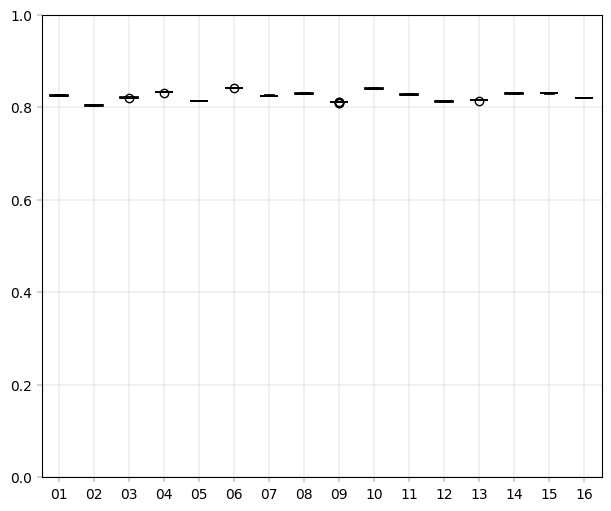

In [ ]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(6, 5))

apt.pl.boxplot(ax=axm[0], data=adata, grouping_column="tmt_plex", value_column="fraction_detected_features")

axm[0].set_ylim(0, 1)
plt.show()

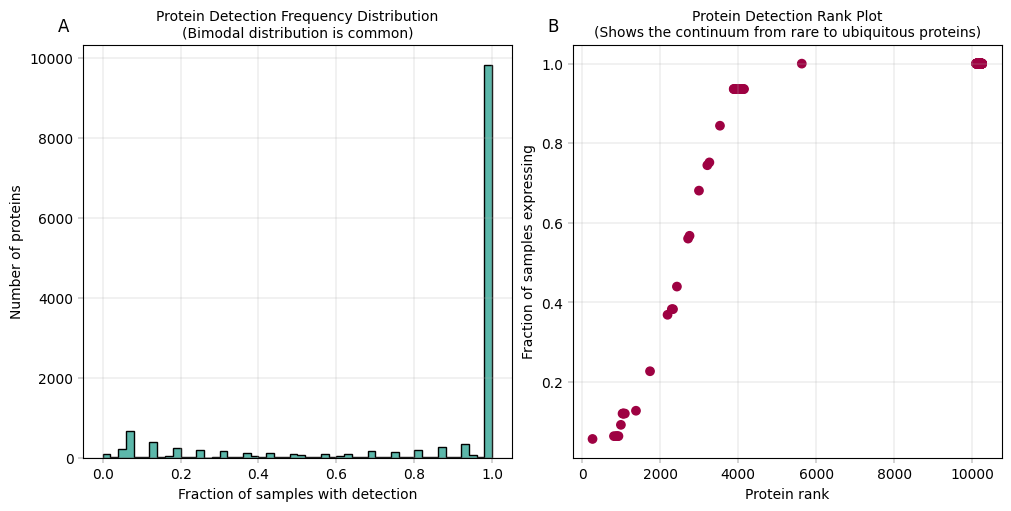

In [ ]:
# Histogram of detection frequency combined with a rank plot
fig, axm = apt.pl.create_figure(1, 2, figsize=(10, 5))

# Histogram
ax = axm.next()
apt.pl.histogram(
    data=adata,
    value_column="fraction_detected_samples",
    bins=50,
    ax=ax,
    color=apt.pl.BaseColors.get("green"),
    hist_kwargs={"histtype": "stepfilled", "edgecolor": "black"},
)

apt.pl.label_axes(
    ax,
    xlabel="Fraction of samples with detection",
    ylabel="Number of proteins",
    title="Protein Detection Frequency Distribution",
    enumeration="A",
)

# Rank plot
protein_ranks = np.argsort(np.argsort(adata.var["fraction_detected_samples"]))
adata.var["protein_rank"] = protein_ranks

ax = axm.next()
apt.pl.scatter(
    data=adata,
    x_column="protein_rank",
    y_column="fraction_detected_samples",
    ax=ax,
    color=apt.pl.BaseColors.get("red"),
)
apt.pl.label_axes(
    ax,
    xlabel="Protein rank",
    ylabel="Fraction of samples expressing",
    title="Protein Detection Rank Plot\n(Shows the continuum from rare to ubiquitous proteins)",
    enumeration="B",
)

In [ ]:
adata = apt.pp.filter_data_completeness(adata, max_missing=0, action="drop")

INFO:root:pp.filter_data_completeness(): drop 4265 / 14058 features with >0.00 missing.


In [ ]:
adata.layers["raw"] = adata.X.copy()

In [ ]:
apt.pp.nanlog(adata)
adata.layers["log2"] = adata.X.copy()

In [ ]:
adata.X = (adata.X - np.nanmedian(adata.X, axis=0)).copy()
adata.layers["median_centered"] = adata.X.copy()

In [ ]:
apt.tl.pca(adata)

INFO:alphapepttools.tl.embeddings:computing PCA


/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


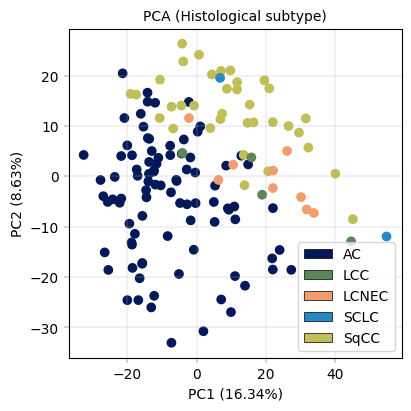

In [ ]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(4, 4))

apt.pl.plot_pca(adata, ax=axm[0], color_map_column="WHO2015_histology", legend="auto")
apt.pl.label_axes(ax=axm[0], title="PCA (Histological subtype)")

## Integrate with complementary modalities

In [ ]:
# TODO: Clean up RNA anndata object
methylation_path = apt.data.get_data("lehtioe2021_methylation")
methylation = ad.read_h5ad(methylation_path)

# TODO: Clean up RNA anndata object
rna_path = apt.data.get_data("lehtioe2021_rna")
rna = ad.read_h5ad(rna_path)

/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/programming/alphatools/docs/notebooks/studies/karlsson2014_nslc_methylation.pp.h5ad already exists (12.016489028930664 MB)
/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/programming/alphatools/docs/notebooks/studies/karlsson2014_nslc_rna.pp.h5ad already exists (13.772186279296875 MB)


/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### Create mudata object

In [ ]:
# TODO: Clean up indices
adata.obs = adata.obs.reset_index(names="sample_id_tmt").set_index("SampleID")
metadata = metadata.reset_index(names="sample_id_tmt").set_index("SampleID")

In [ ]:
mdata = md.MuData({"proteins": adata, "rna": rna, "methylation": methylation})

mdata.obs = mdata.obs.merge(metadata, left_index=True, right_index=True)

# TODO: Remove/Clean up metadata
mdata.obs = mdata.obs.dropna(axis=1)

mdata

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/

MuData object with n_obs × n_vars = 141 × 36278
  obs:	'sample_id_tmt', 'Proteome Subtype', 'Age', 'Sex', 'Previous_histology', 'WHO2015_histology', 'AC_mRNA_Subtype TCGA', 'SqCC_mRNA_Subtype TCGA', 'NSCLC_mRNA_Subtype Karlsson et al. 2017', 'SmokingStatus', 'SmokingStatus_Binary', 'Stage_general', 'Stage_detailed', 'OS_years', 'OSbin', 'Relapse_years', 'Relapse_bin', 'Adjuvant_therapy', 'PDL1_IHC', 'CD3_Stromal_IHC', 'CD8_Stromal_IHC', 'Stroma_Estimate', 'Immune_Estimate', 'ARID1A_mut', 'ARID2_mut', 'ASXL1_mut', 'ATM_mut', 'BLM_mut', 'BRAF_mut', 'CDKN2A_mut', 'EGFR_mut', 'FAT1_mut', 'KEAP1_mut', 'KMT2C_mut', 'KMT2D_mut', 'KRAS_mut', 'NF1_mut', 'NFE2L2_mut', 'NOTCH2_mut', 'PIK3CA_mut', 'POLD1_mut', 'PTEN_mut', 'RB1_mut', 'RBM10_mut', 'SMARCA4_mut', 'STK11_mut', 'TP53_mut', 'ZFHX3_mut', 'TMB', 'Cancer_Testis_Antigens', 'NCPs', 'Purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'MethylationPresent', 'PanelSeqPresent', 'TranscriptomicsPresent'
  3 modalities
    proteins:	141 x 9793
      obs:	'sample_id_tmt', 'Proteome Subtype', 'Age', 'Sex', 'Previous_histology', 'WHO2015_histology', 'AC_mRNA_Subtype TCGA', 'SqCC_mRNA_Subtype TCGA', 'NSCLC_mRNA_Subtype Karlsson et al. 2017', 'SmokingStatus', 'SmokingStatus_Binary', 'Stage_general', 'Stage_detailed', 'OS_years', 'OSbin', 'Relapse_years', 'Relapse_bin', 'Adjuvant_therapy', 'PDL1_IHC', 'CD3_Stromal_IHC', 'CD8_Stromal_IHC', 'Stroma_Estimate', 'Immune_Estimate', 'ARID1A_mut', 'ARID2_mut', 'ASXL1_mut', 'ATM_mut', 'BLM_mut', 'BRAF_mut', 'CDKN2A_mut', 'EGFR_mut', 'FAT1_mut', 'KEAP1_mut', 'KMT2C_mut', 'KMT2D_mut', 'KRAS_mut', 'NF1_mut', 'NFE2L2_mut', 'NOTCH2_mut', 'PIK3CA_mut', 'POLD1_mut', 'PTEN_mut', 'RB1_mut', 'RBM10_mut', 'SMARCA4_mut', 'STK11_mut', 'TP53_mut', 'ZFHX3_mut', 'TMB', 'Cancer_Testis_Antigens', 'NCPs', 'Purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'MethylationPresent', 'PanelSeqPresent', 'TranscriptomicsPresent', 'total_sample_intensity', 'num_features_detected', 'fraction_detected_features', 'log10_sum_intensity', 'tmt_plex', 'tmt_channel'
      var:	'description', 'protein_coverage', 'n_proteins', 'proteins', 'total_feature_intensity', 'num_samples_detected', 'fraction_detected_samples', 'protein_rank'
      uns:	'variance_pca_obs'
      obsm:	'X_pca_obs'
      varm:	'PCs_pca_obs'
      layers:	'raw', 'log2', 'median_centered'
    rna:	118 x 14548
      obs:	'TMT set and label', 'Proteome Subtype', 'Age', 'Sex', 'Previous_histology', 'WHO2015_histology', 'AC_mRNA_Subtype TCGA', 'SqCC_mRNA_Subtype TCGA', 'NSCLC_mRNA_Subtype Karlsson et al. 2017', 'SmokingStatus', 'SmokingStatus_Binary', 'Stage_general', 'Stage_detailed', 'OS_years', 'OSbin', 'Relapse_years', 'Relapse_bin', 'Adjuvant_therapy', 'PDL1_IHC', 'CD3_Stromal_IHC', 'CD8_Stromal_IHC', 'Stroma_Estimate', 'Immune_Estimate', 'ARID1A_mut', 'ARID2_mut', 'ASXL1_mut', 'ATM_mut', 'BLM_mut', 'BRAF_mut', 'CDKN2A_mut', 'EGFR_mut', 'FAT1_mut', 'KEAP1_mut', 'KMT2C_mut', 'KMT2D_mut', 'KRAS_mut', 'NF1_mut', 'NFE2L2_mut', 'NOTCH2_mut', 'PIK3CA_mut', 'POLD1_mut', 'PTEN_mut', 'RB1_mut', 'RBM10_mut', 'SMARCA4_mut', 'STK11_mut', 'TP53_mut', 'ZFHX3_mut', 'TMB', 'Cancer_Testis_Antigens', 'NCPs', 'Purity', 'methylation_scores_overall', 'methylation_scores_promoter', 'MethylationPresent', 'PanelSeqPresent', 'TranscriptomicsPresent'
    methylation:	113 x 11937
      obs:	'TMT set and label', 'Proteome Subtype', 'Age', 'Sex', 'Previous_histology', 'WHO2015_histology', 'AC_mRNA_Subtype TCGA', 'SqCC_mRNA_Subtype TCGA', 'NSCLC_mRNA_Subtype Karlsson et al. 2017', 'SmokingStatus', 'SmokingStatus_Binary', 'Stage_general', 'Stage_detailed', 'OS_years', 'OSbin', 'Relapse_years', 'Relapse_bin', 'Adjuvant_therapy', 'PDL1_IHC', 'CD3_Stromal_IHC', 'CD8_Stromal_IHC', 'Stroma_Estimate', 'Immune_Estimate', 'ARID1A_mut', 'ARID2_mut', 'ASXL1_mut', 'ATM_mut', 'BLM_mut', 'BRAF_mut', 'CDKN2A_mut', 'EGFR_mut', 'FAT1_mut', 'KEAP1_mut', 'KMT2C_mut', 'KMT2D_mut', 'KRAS_mut', 'NF1_mut', 'NFE2L2_mut', 'NOTCH2_mut', 'PI

### Run MOFA+ factor analysis 

In [ ]:
mofa_kwargs = {
    "use_obs": "union",
    "n_factors": 25,
    "scale_groups": True,
    "scale_views": True,
    "ard_weights": True,
    "ard_factors": True,
    "use_var": "highly_variable",
    "likelihoods": "gaussian",
    "convergence_mode": "slow",
    "seed": 1,
}

In [ ]:
# Runs 5min on MacOS + M4
muon.tl.mofa(mdata, **mofa_kwargs)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Scaling groups to unit variance...

Loaded view='proteins' group='group1' with N=141 samples and D=9793 features...
Loaded view='rna' group='group1' with N=141 samples and D=14548 features...
Loaded view='methylation' group='group1' with N=141 samples and D=11937 features...


Model options:
- Automatic Relevance Determination prior on the factors: Tr

## Exploration

... storing 'proteins:Sex' as categorical
... storing 'proteins:Previous_histology' as categorical
... storing 'proteins:WHO2015_histology' as categorical
... storing 'proteins:SmokingStatus' as categorical
... storing 'proteins:SmokingStatus_Binary' as categorical
... storing 'proteins:tmt_plex' as categorical
... storing 'proteins:tmt_channel' as categorical
... storing 'Sex' as categorical
... storing 'Previous_histology' as categorical
... storing 'WHO2015_histology' as categorical
... storing 'SmokingStatus' as categorical
... storing 'SmokingStatus_Binary' as categorical


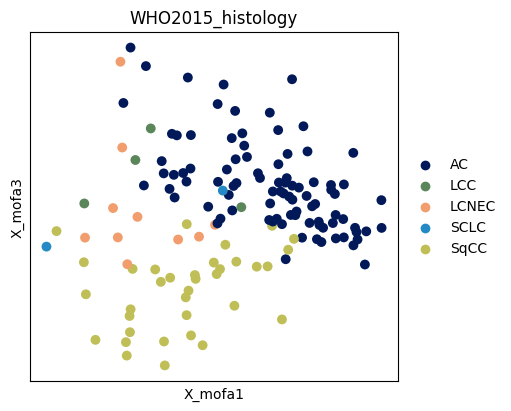

In [ ]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(5, 4))

muon.pl.embedding(
    mdata,
    basis="X_mofa",
    color="WHO2015_histology",
    dimensions=(0, 2),
    palette=apt.pl.BasePalettes().get("qualitative"),
    size=200,
    ax=axm[0],
)

apt.pl.label_axes(title="MOFA+ (Histological subtype)", ax=axm[0])

<Axes: >

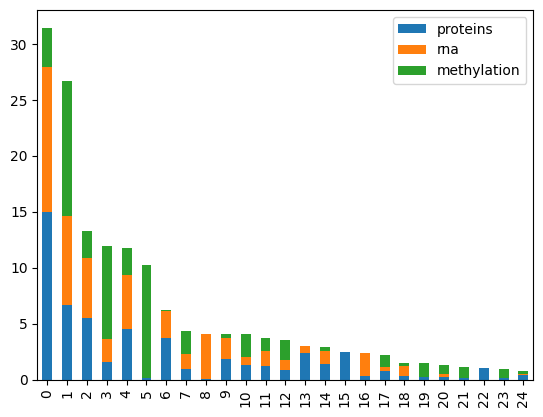

In [ ]:
pd.DataFrame(mdata.uns["mofa"]["variance"]).plot.bar(stacked=True)

### Separation of samples

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
silhouette_score(adata.obsm["X_pca_obs"][:, :20], labels=adata.obs["WHO2015_histology"])

0.12119472771883011

In [ ]:
silhouette_score(mdata.obsm["X_mofa"][:, :20], labels=mdata.obs["WHO2015_histology"])

0.13841043288844943

### Correlation of modalities

## Session Info 

In [ ]:
from session_info2 import session_info

session_info()

Package,Version
matplotlib,3.10.8
anndata,0.12.10
alphapepttools,0.2.1.dev0 (0.2.1-dev0)
mudata,0.3.3
muon,0.1.7
pandas,2.3.3
alphabase,1.8.1
numpy,2.3.5
Component,Info
Python,"3.13.12 | packaged by conda-forge | (main, Feb 5 2026, 06:11:05) [Clang 19.1.7 ]"
